## Problem 11.7 - Regression with shallow neural networks from scratch

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

In [108]:
# generating data
np.random.seed(42)
n = 100
X = np.random.uniform(0, 1, n)
noise = np.random.normal(0, 0.3, X.shape)
y = np.sin(3 * np.pi * X) + noise

In [109]:
# define needed parameters 
max_it = 3000
lamda = 0.001
m = 40
stepsize = 0.05
W1 = np.random.uniform(-10, 10, (m, 1))
b1 = np.random.uniform(-10, 10, (m, 1))
W2 = np.random.uniform(-10, 10, (1, m))
b2 = np.random.uniform(-10, 10, (1, 1))

In [110]:
def f(x, W1, b1, W2, b2):
    z1 = W1 * x + b1
    a1 = np.tanh(z1)
    z2 = W2 @ a1 + b2
    return z2

In [111]:
def f_vectorized(X, W1, b1, W2, b2):
    X = X.reshape(1, -1)       
    Z1 = W1 @ X + b1            
    A1 = np.tanh(Z1)            
    Z2 = W2 @ A1 + b2           
    return Z2.flatten()

In [112]:
# define function G and use gradient descent to optimize theta
def G(W1, b1, W2, b2):
    y_hat = f_vectorized(X, W1, b1, W2, b2)
    return np.mean((y - y_hat)**2) + lamda * (np.sum(W1**2) + np.sum(b1**2) + np.sum(W2**2) + np.sum(b2**2))

In [136]:
# compute the parts of the gradient
def compute_gradients(W1, b1, W2, b2):
    grad_W1 = np.zeros_like(W1)
    grad_b1 = np.zeros_like(b1)
    grad_W2 = np.zeros_like(W2)
    grad_b2 = np.zeros_like(b2)

    for i in range(n):
        y_hat_i = f(X[i], W1, b1, W2, b2)
        z1 = W1 * X[i]+ b1
        a1 = np.tanh(z1)

        grad_W1 += -2 * (y[i] - y_hat_i) * W2.T * (1 - a1**2) * X[i]
        grad_b1 += -2 * (y[i] - y_hat_i) * W2.T * (1 - a1**2)
        grad_W2 += -2 * (y[i] - y_hat_i) * a1.T
        grad_b2 += -2 * (y[i] - y_hat_i) 

    grad_W1 = grad_W1 / n + 2 * lamda * W1
    grad_b1 = grad_b1 / n + 2 * lamda * b1
    grad_W2 = grad_W2 / n + 2 * lamda * W2
    grad_b2 = grad_b2 / n + 2 * lamda * b2

    return grad_W1, grad_b1, grad_W2, grad_b2

In [142]:
# define function that performs one step of the gradient descent
def gradient_step(grad_W1, grad_b1, grad_W2, grad_b2, stepsize):
    W1_new = W1 - stepsize * grad_W1
    b1_new = b1 - stepsize * grad_b1
    W2_new = W2 - stepsize * grad_W2
    b2_new = b2 - stepsize * grad_b2
    return W1_new, b1_new, W2_new, b2_new

In [143]:
# define a function for the whole gradient descent algorithm
def gradient_descent(W1, b1, W2, b2, stepsize, max_it):
    G_values = []
    for iteration in range(max_it):
        G_values.append(G(W1, b1, W2, b2))
        grad_W1, grad_b1, grad_W2, grad_b2 = compute_gradients(W1, b1, W2, b2)
        W1, b1, W2, b2 = gradient_step(grad_W1, grad_b1, grad_W2, grad_b2, stepsize)
    return W1, b1, W2, b2, G_values

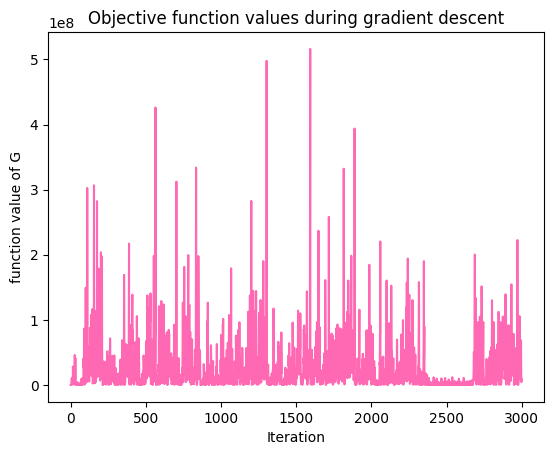

In [144]:
# apply the gradient descent algorithm to our data and plot the objectve function values
W1_opt, b1_opt, W2_opt, b2_opt, G_values = gradient_descent(W1, b1, W2, b2, stepsize, max_it)
plt.plot(G_values, color = 'hotpink')
plt.xlabel('Iteration')
plt.ylabel('function value of G')
plt.title('Objective function values during gradient descent')
plt.show()

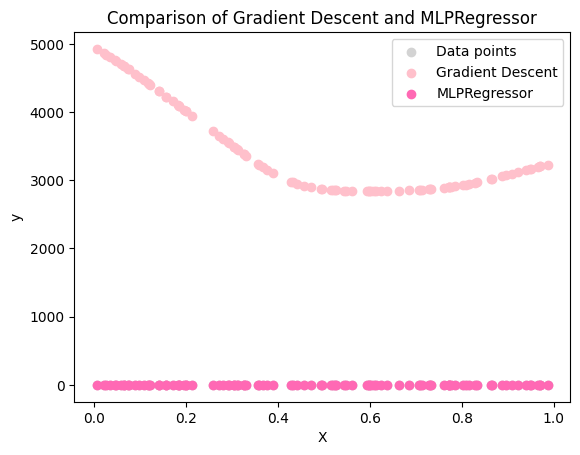

In [145]:
# compare to results with MLPRegressor
mlp = MLPRegressor(hidden_layer_sizes = (m,), activation = 'tanh', alpha = lamda, max_iter = max_it, random_state = 0)
mlp.fit(X.reshape(-1, 1), y)
y_mlp = mlp.predict(X.reshape(-1, 1))
y_grad_descent = f_vectorized(X, W1_opt, b1_opt, W2_opt, b2_opt)
plt.scatter(X, y, color = 'lightgray', label = 'Data points')
plt.scatter(X, y_grad_descent, color = 'pink', label = 'Gradient Descent')
plt.scatter(X, y_mlp, color = 'hotpink', label = 'MLPRegressor')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Comparison of Gradient Descent and MLPRegressor')
plt.legend()
plt.show()